# 방식 C: 듀얼 타임프레임 — 모멘텀 유니버스 + %R 일간 비중 조절

**구조:**
- 매월 초: 모멘텀(12-1 & 6-1) 랭킹으로 투자 유니버스 N종목 확정
- 유니버스는 항상 유지하되, 각 종목의 **실제 투자 비중**을 %R 상태에 따라 일간 조절
  - %R(14)가 -80 이하 → -80 위로 크로스: **비중 100%** (= 1/N)로 진입, 다음날 시가 체결
  - %R(14)가 -20 이상 → -20 아래로 크로스 + 쿨다운 만료: **비중 0%**로 청산, 다음날 시가 체결
  - 그 외: 현재 비중 유지 (신호 없으면 건드리지 않음)
- 쿨다운: 매수 후 N개월 내에는 %R 매도 신호가 나와도 포지션 유지
- 폴백: 월말까지 %R 매수 신호 없는 유니버스 종목은 월말 강제 매수 (옵션)

**A/B와의 차이:**
- A: %R이 진입/청산 **전부** 담당 (들어가거나 나오거나)
- B: %R이 월간 **사전 필터**로만 사용
- C: 유니버스는 월간 고정, 비중은 %R로 **연속적 일간 관리** → 가장 능동적

**룩어헤드 방지:**
- 모멘텀 신호: 전월 말 확정 종가 (월별 shift)
- %R(14): 당일까지 확정된 H/L/C → 신호 발생 **다음날 시가** 체결
- 백테스트 루프: 일간

In [ ]:
# ============================================================
# [CELL 1] CONFIG
# ============================================================

CONFIG = {
    # ── 기간 ──
    "START_DATE": "2010-01-01",
    "END_DATE": "2025-01-01",
    "WARMUP_MONTHS": 13,

    # ── 모멘텀 ──
    "N_MOM": 8,
    "MOM_WEIGHT_12": 0.5,
    "MOM_WEIGHT_6": 0.5,

    # ── %R ──
    "WR_PERIOD": 14,
    "WR_BUY_LEVEL": -80,     # 이 아래 → 위로 크로스: 비중 100%
    "WR_SELL_LEVEL": -20,    # 이 위 → 아래로 크로스: 비중 0%

    # ── 쿨다운 ──
    "COOLDOWN_MONTHS": 3,

    # ── 비용 & 자본 ──
    "COST_RATE": 0.003,
    "INITIAL_CAPITAL": 100_000_000,

    # ── 폴백 ──
    "FORCE_BUY_ON_MONTH_END": True,

    # ── KRX OHLCV CSV (로컬 데이터) ──
    "KRX_CSV": r"C:\Users\jeeho\Desktop\pj3\project3\krx_ohlcv_20100101_20261231.csv",

    # ── 데이터 품질 ──
    "MIN_HISTORY_DAYS": 260,
}

print("✅ CONFIG 설정 완료")
for k, v in CONFIG.items():
    if not isinstance(v, list):
        print(f"   {k}: {v}")

✅ CONFIG 설정 완료
   START_DATE: 2010-01-01
   END_DATE: 2025-01-01
   WARMUP_MONTHS: 13
   N_MOM: 8
   MOM_WEIGHT_12: 0.5
   MOM_WEIGHT_6: 0.5
   WR_PERIOD: 14
   WR_BUY_LEVEL: -80
   WR_SELL_LEVEL: -20
   COOLDOWN_MONTHS: 3
   COST_RATE: 0.003
   INITIAL_CAPITAL: 100000000
   FORCE_BUY_ON_MONTH_END: True
   TICKER_CSV: 코스피 지수 198종목.csv
   TICKER_CSV_ENCODING: cp949
   MIN_HISTORY_DAYS: 260


In [ ]:
# ============================================================
# [CELL 2] 라이브러리
# ============================================================

import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.style.use("fivethirtyeight")

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


In [ ]:
# ============================================================
# [CELL 3] KRX CSV 로드 & 종목 티커 추출
# ============================================================

csv_path = CONFIG["KRX_CSV"]

df_krx = pd.read_csv(csv_path)
df_krx["Date"] = pd.to_datetime(df_krx["Date"])
df_krx["ticker"] = df_krx["ticker"].astype(str).str.zfill(6)

# 기간 필터
df_krx = df_krx[(df_krx["Date"] >= CONFIG["START_DATE"]) & (df_krx["Date"] <= CONFIG["END_DATE"])]

tickers = sorted(df_krx["ticker"].unique())
print(f"✅ KRX CSV 로드 완료: {csv_path}")
print(f"   총 {len(tickers)}개 종목, {len(df_krx):,}행 데이터")
print(f"   기간: {df_krx['Date'].min().strftime('%Y-%m-%d')} ~ {df_krx['Date'].max().strftime('%Y-%m-%d')}")

'코스피 지수 198종목.csv' 없음. 폴백 티커 사용.
총 12개 티커 준비


In [ ]:
# ============================================================
# [CELL 4] 데이터 로드: 일간 OHLC + %R + 월간 모멘텀 (KRX CSV)
# ============================================================

stocks_daily = {}    # {ticker: DataFrame[Open, High, Low, Close, WR]}
stocks_monthly = {}  # {ticker: DataFrame[Close, Momentum]}

WR_N = CONFIG["WR_PERIOD"]

for t in tqdm(tickers, desc="데이터 처리",
              bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{percentage:3.0f}%]"):
    sub = df_krx[df_krx["ticker"] == t].set_index("Date").sort_index()

    if len(sub) < CONFIG["MIN_HISTORY_DAYS"]:
        continue

    # ── 일간: %R(14) ──
    highest = sub["High"].rolling(WR_N).max()
    lowest  = sub["Low"].rolling(WR_N).min()
    denom   = highest - lowest
    sub["WR"] = np.where(denom > 0,
                         (highest - sub["Close"]) / denom * (-100),
                         np.nan)

    stocks_daily[t] = sub[["Open", "High", "Low", "Close", "WR"]].copy()

    # ── 월간: 모멘텀 ──
    monthly = sub["Close"].resample("ME").last().dropna().to_frame("Close")
    monthly["Mom_12_1"] = monthly["Close"].shift(1) / monthly["Close"].shift(12) - 1
    monthly["Mom_6_1"]  = monthly["Close"].shift(1) / monthly["Close"].shift(6) - 1
    w12, w6 = CONFIG["MOM_WEIGHT_12"], CONFIG["MOM_WEIGHT_6"]
    monthly["Momentum"] = w12 * monthly["Mom_12_1"] + w6 * monthly["Mom_6_1"]
    monthly = monthly.dropna(subset=["Momentum"])
    if len(monthly) > 0:
        stocks_monthly[t] = monthly

valid_tickers = set(stocks_daily.keys()) & set(stocks_monthly.keys())
stocks_daily   = {t: v for t, v in stocks_daily.items() if t in valid_tickers}
stocks_monthly = {t: v for t, v in stocks_monthly.items() if t in valid_tickers}

print(f"\n분석 가능 종목: {len(valid_tickers)}개")

데이터 다운로드: 100%|██████████| 12/12 [100%]


분석 가능 종목: 12개


In [5]:
# ============================================================
# [CELL 5] 거래일 인덱스 & 리밸런싱 날짜
# ============================================================

all_dates = sorted(set().union(*(df.index.tolist() for df in stocks_daily.values())))
daily_index = pd.DatetimeIndex(all_dates)

# 매월 첫 거래일 (유니버스 갱신)
rebal_dates = daily_index.to_series().groupby(
    [daily_index.year, daily_index.month]
).first().values
rebal_dates = pd.DatetimeIndex(sorted(rebal_dates))

# 매월 마지막 거래일 (폴백 강제 매수)
month_end_dates = daily_index.to_series().groupby(
    [daily_index.year, daily_index.month]
).last().values
month_end_set = set(pd.DatetimeIndex(sorted(month_end_dates)))

# 워밍업 제거
warmup_end = pd.Timestamp(CONFIG["START_DATE"]) + pd.DateOffset(months=CONFIG["WARMUP_MONTHS"])
trade_start = rebal_dates[rebal_dates >= warmup_end][0]
trading_days = daily_index[daily_index >= trade_start]
rebal_dates = rebal_dates[rebal_dates >= trade_start]
rebal_set = set(rebal_dates)

print(f"트레이딩 기간: {trading_days[0].strftime('%Y-%m-%d')} ~ {trading_days[-1].strftime('%Y-%m-%d')}")
print(f"총 거래일: {len(trading_days)}일, 유니버스 갱신: {len(rebal_dates)}회")

트레이딩 기간: 2011-02-01 ~ 2024-12-30
총 거래일: 3422일, 유니버스 갱신: 167회


In [6]:
# ============================================================
# [CELL 6] 백테스트 엔진 (일간 루프)
# ============================================================
#
# ★ 핵심 구조:
#   universe[] = 모멘텀 상위 N종목 (매월 갱신)
#   holdings{} = 실제 보유 포지션
#
#   유니버스에 있지만 보유하지 않은 종목 = "대기" 상태
#     → %R 매수 크로스 → 다음날 시가 매수 (비중 1/N)
#   유니버스에 있고 보유 중인 종목:
#     → 쿨다운 만료 + %R 매도 크로스 → 다음날 시가 매도
#     → 쿨다운 중이면 매도 신호 무시
#   유니버스에서 탈락한 보유 종목:
#     → 쿨다운 만료 시 다음 리밸런싱에서 매도 예약
#
# ★ 방식 A와의 차이:
#   A는 유니버스 = 타깃 (빠지면 무조건 매도 방향)
#   C는 유니버스 = 투자 풀, 실제 보유 여부는 %R이 결정
#   → C에서는 유니버스 내 종목이 %R 매도 후에도 유니버스에 남아있으면
#     다시 %R 매수 신호가 오면 재진입 가능
#
# ★ 룩어헤드 방지:
#   - %R: 당일 종가까지 계산(확정) → 다음날 시가 체결
#   - 모멘텀: 전월 말 확정 데이터
#

def get_momentum(ticker, rebal_date):
    if ticker not in stocks_monthly:
        return None
    df = stocks_monthly[ticker]
    avail = df.loc[:rebal_date - pd.Timedelta(days=1)]
    if avail.empty:
        return None
    return avail["Momentum"].iloc[-1]


def run_backtest_C():
    cash = CONFIG["INITIAL_CAPITAL"]
    holdings = {}      # {ticker: {"shares": int, "buy_date": Timestamp}}
    universe = []      # 현재 월의 투자 유니버스 (모멘텀 상위 N)

    buy_tomorrow = {}   # {ticker: True}
    sell_tomorrow = {}  # {ticker: True}

    history = []
    trade_log = []
    total_traded = 0.0
    exposure_log = []   # 일별 투자 비중 추적

    N = CONFIG["N_MOM"]
    COOLDOWN = CONFIG["COOLDOWN_MONTHS"]
    COST = CONFIG["COST_RATE"]
    BUY_LV = CONFIG["WR_BUY_LEVEL"]
    SELL_LV = CONFIG["WR_SELL_LEVEL"]

    prev_wr = {}  # {ticker: 전일 %R}

    trading_days_list = list(trading_days)

    for i, today in enumerate(trading_days_list):

        # ============================================
        # (A) 예약 주문 체결 (전일 신호 → 오늘 시가)
        # ============================================

        # 매수 체결
        for t in list(buy_tomorrow.keys()):
            if t in stocks_daily and today in stocks_daily[t].index:
                open_p = stocks_daily[t].loc[today, "Open"]
                if pd.notna(open_p) and open_p > 0:
                    # 포트폴리오 가치 계산 (시가 기준)
                    port_val = cash
                    for ht, hi in holdings.items():
                        if ht in stocks_daily and today in stocks_daily[ht].index:
                            port_val += hi["shares"] * stocks_daily[ht].loc[today, "Open"]

                    alloc = port_val / max(N, 1)
                    shares = int(alloc // open_p)
                    cost = shares * open_p * (1 + COST)
                    if shares > 0 and cash >= cost:
                        cash -= cost
                        total_traded += shares * open_p
                        holdings[t] = {"shares": shares, "buy_date": today}
                        trade_log.append((today, t, "BUY", shares, open_p))
            buy_tomorrow.pop(t, None)

        # 매도 체결
        for t in list(sell_tomorrow.keys()):
            if t in holdings and t in stocks_daily and today in stocks_daily[t].index:
                open_p = stocks_daily[t].loc[today, "Open"]
                if pd.notna(open_p) and open_p > 0:
                    traded_val = holdings[t]["shares"] * open_p
                    cash += traded_val * (1 - COST)
                    total_traded += traded_val
                    trade_log.append((today, t, "SELL", holdings[t]["shares"], open_p))
                    del holdings[t]
            sell_tomorrow.pop(t, None)

        # ============================================
        # (B) 리밸런싱일: 유니버스 갱신
        # ============================================
        if today in rebal_set:
            # 모멘텀 랭킹
            mom_scores = []
            for t in valid_tickers:
                mom = get_momentum(t, today)
                if mom is not None and t in stocks_daily and today in stocks_daily[t].index:
                    mom_scores.append((t, mom))
            mom_scores.sort(key=lambda x: x[1], reverse=True)

            # 쿨다운 보호 종목
            cooldown_keep = []
            for t, info in holdings.items():
                months_held = ((today.year - info["buy_date"].year) * 12
                               + (today.month - info["buy_date"].month))
                if months_held < COOLDOWN:
                    cooldown_keep.append(t)

            # 유니버스 = 쿨다운 종목 + 모멘텀 상위
            universe = cooldown_keep.copy()
            for t, _ in mom_scores:
                if len(universe) >= N:
                    break
                if t not in universe:
                    universe.append(t)

            # 유니버스에서 탈락한 보유 종목: 쿨다운 만료 시 매도 예약
            for t in list(holdings.keys()):
                if t not in universe:
                    months_held = ((today.year - holdings[t]["buy_date"].year) * 12
                                   + (today.month - holdings[t]["buy_date"].month))
                    if months_held >= COOLDOWN:
                        sell_tomorrow[t] = True

        # ============================================
        # (C) 일간 %R 신호 감시
        # ============================================

        # 유니버스 내 미보유 종목: %R 매수 크로스
        for t in universe:
            if t in holdings or t in buy_tomorrow:
                continue  # 이미 보유 또는 매수 예약
            if t not in stocks_daily or today not in stocks_daily[t].index:
                continue

            wr_today = stocks_daily[t].loc[today, "WR"]
            wr_prev = prev_wr.get(t, np.nan)

            if pd.notna(wr_today) and pd.notna(wr_prev):
                if wr_prev <= BUY_LV and wr_today > BUY_LV:
                    buy_tomorrow[t] = True

        # 보유 종목: %R 매도 크로스 (쿨다운 만료 + 유니버스 내외 무관)
        for t, info in holdings.items():
            if t in sell_tomorrow:
                continue
            months_held = ((today.year - info["buy_date"].year) * 12
                           + (today.month - info["buy_date"].month))
            if months_held < COOLDOWN:
                continue

            if t not in stocks_daily or today not in stocks_daily[t].index:
                continue
            wr_today = stocks_daily[t].loc[today, "WR"]
            wr_prev = prev_wr.get(t, np.nan)

            if pd.notna(wr_today) and pd.notna(wr_prev):
                if wr_prev >= SELL_LV and wr_today < SELL_LV:
                    sell_tomorrow[t] = True

        # ============================================
        # (D) 월말 폴백: 유니버스 내 미보유 종목 강제 매수
        # ============================================
        if CONFIG["FORCE_BUY_ON_MONTH_END"] and today in month_end_set:
            for t in universe:
                if t not in holdings and t not in buy_tomorrow:
                    buy_tomorrow[t] = True

        # ============================================
        # (E) 전일 %R 업데이트 & 기록
        # ============================================
        for t in valid_tickers:
            if t in stocks_daily and today in stocks_daily[t].index:
                wr_val = stocks_daily[t].loc[today, "WR"]
                if pd.notna(wr_val):
                    prev_wr[t] = wr_val

        # 포트 가치 (종가 기준)
        port_val = cash
        invested = 0.0
        for t, info in holdings.items():
            if t in stocks_daily and today in stocks_daily[t].index:
                val = info["shares"] * stocks_daily[t].loc[today, "Close"]
                port_val += val
                invested += val
        history.append((today, port_val))

        # 투자 비중 기록
        exposure_pct = (invested / port_val * 100) if port_val > 0 else 0
        n_held = len(holdings)
        exposure_log.append((today, exposure_pct, n_held, len(universe)))

    # 결과
    perf_df = pd.DataFrame(history, columns=["Date", "Value"]).set_index("Date")
    trade_df = pd.DataFrame(trade_log, columns=["Date", "Ticker", "Action", "Shares", "Price"])
    exposure_df = pd.DataFrame(exposure_log,
                               columns=["Date", "Exposure%", "N_Held", "N_Universe"]).set_index("Date")
    return perf_df, trade_df, total_traded, exposure_df


print("✅ 백테스트 엔진 정의 완료")

✅ 백테스트 엔진 정의 완료


In [7]:
# ============================================================
# [CELL 7] 백테스트 실행
# ============================================================

perf_df, trade_df, total_traded, exposure_df = run_backtest_C()

print(f"백테스트 완료")
print(f"  시작 자산: {CONFIG['INITIAL_CAPITAL']:>20,} 원")
print(f"  최종 자산: {perf_df['Value'].iloc[-1]:>20,.0f} 원")
print(f"  총 매매 건수: {len(trade_df)}건")
print(f"\n매매 유형 분포:")
print(trade_df["Action"].value_counts().to_string())
print(f"\n평균 투자 비중: {exposure_df['Exposure%'].mean():.1f}%")
print(f"평균 보유 종목 수: {exposure_df['N_Held'].mean():.1f}개 / 유니버스 {CONFIG['N_MOM']}개")

백테스트 완료
  시작 자산:          100,000,000 원
  최종 자산:          232,126,171 원
  총 매매 건수: 678건

매매 유형 분포:
Action
BUY     343
SELL    335

평균 투자 비중: 82.4%
평균 보유 종목 수: 6.6개 / 유니버스 8개


In [8]:
# ============================================================
# [CELL 8] 성과 분석
# ============================================================

def compute_metrics(df, initial_capital, traded_sum):
    monthly = df["Value"].resample("ME").last().dropna()
    returns = monthly.pct_change().dropna()
    years = max((df.index[-1] - df.index[0]).days / 365.25, 0.1)

    final = df["Value"].iloc[-1]
    cagr = ((final / initial_capital) ** (1 / years) - 1) * 100
    cum_ret = (final / initial_capital - 1) * 100

    running_max = df["Value"].cummax()
    mdd = (df["Value"] / running_max - 1).min() * 100

    sharpe = (returns.mean() * 12) / (returns.std() * np.sqrt(12)) if returns.std() > 0 else 0
    turnover = (traded_sum / 2) / df["Value"].mean() / years * 100

    return {
        "누적 수익률": f"{cum_ret:.2f}%",
        "CAGR": f"{cagr:.2f}%",
        "MDD": f"{mdd:.2f}%",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "연간 회전율": f"{turnover:.1f}%",
        "최종 자산": f"{final:,.0f} 원",
    }


metrics = compute_metrics(perf_df, CONFIG["INITIAL_CAPITAL"], total_traded)
print(f"{'='*50}")
print(f"  [방식 C] 전략 성과 요약")
print(f"{'='*50}")
summary_df = pd.DataFrame(list(metrics.items()), columns=["지표", "값"])
display(summary_df.style.hide(axis="index").set_properties(**{"text-align": "left", "padding": "8px"}))

  [방식 C] 전략 성과 요약


지표,값
누적 수익률,132.13%
CAGR,6.24%
MDD,-36.90%
Sharpe Ratio,0.46
연간 회전율,307.6%
최종 자산,"232,126,171 원"


In [9]:
# ============================================================
# [CELL 9] 연도별 성과
# ============================================================

def yearly_analysis(df, initial_capital):
    yearly = df["Value"].resample("YE").last()
    yearly_ret = yearly.pct_change()
    yearly_ret.iloc[0] = yearly.iloc[0] / initial_capital - 1
    yearly_mdd = df.groupby(df.index.year)["Value"].apply(
        lambda x: (x / x.cummax() - 1).min()
    )
    return pd.DataFrame({
        "연도": yearly_ret.index.year,
        "수익률(%)": (yearly_ret.values * 100).round(2),
        "MDD(%)": (yearly_mdd.values * 100).round(2),
    })

yearly_df = yearly_analysis(perf_df, CONFIG["INITIAL_CAPITAL"])
print(f"{'='*50}")
print(f"  [방식 C] 연도별 성과")
print(f"{'='*50}")
display(yearly_df.style.hide(axis="index")
        .format({"수익률(%)": "{:.2f}", "MDD(%)": "{:.2f}"})
        .set_properties(**{"text-align": "center", "padding": "8px"}))

  [방식 C] 연도별 성과


연도,수익률(%),MDD(%)
2011,2.24,-18.05
2012,-4.79,-18.50
2013,6.50,-11.04
2014,-6.51,-11.57
2015,-3.68,-17.64
2016,1.16,-8.94
2017,48.82,-7.72
2018,-12.19,-24.26
2019,4.64,-10.78
2020,56.66,-30.71


In [10]:
# ============================================================
# [CELL 10] 월간 세부 통계
# ============================================================

monthly_val = perf_df["Value"].resample("ME").last().dropna()
monthly_ret = monthly_val.pct_change().dropna()

win = monthly_ret[monthly_ret > 0]
lose = monthly_ret[monthly_ret < 0]

detail = {
    "월간 승률": f"{len(win)/len(monthly_ret)*100:.1f}%",
    "평균 상승월": f"{win.mean()*100:.2f}%" if len(win) > 0 else "N/A",
    "평균 하락월": f"{lose.mean()*100:.2f}%" if len(lose) > 0 else "N/A",
    "Profit Factor": f"{abs(win.sum()/lose.sum()):.2f}" if len(lose) > 0 else "N/A",
    "최고 월간": f"{monthly_ret.max()*100:.2f}%",
    "최저 월간": f"{monthly_ret.min()*100:.2f}%",
}

print(f"{'='*50}")
print(f"  [방식 C] 월간 세부 통계")
print(f"{'='*50}")
detail_df = pd.DataFrame(list(detail.items()), columns=["항목", "값"])
display(detail_df.style.hide(axis="index").set_properties(**{"text-align": "left", "padding": "8px"}))

  [방식 C] 월간 세부 통계


항목,값
월간 승률,51.2%
평균 상승월,4.26%
평균 하락월,-3.14%
Profit Factor,1.42
최고 월간,18.05%
최저 월간,-12.85%


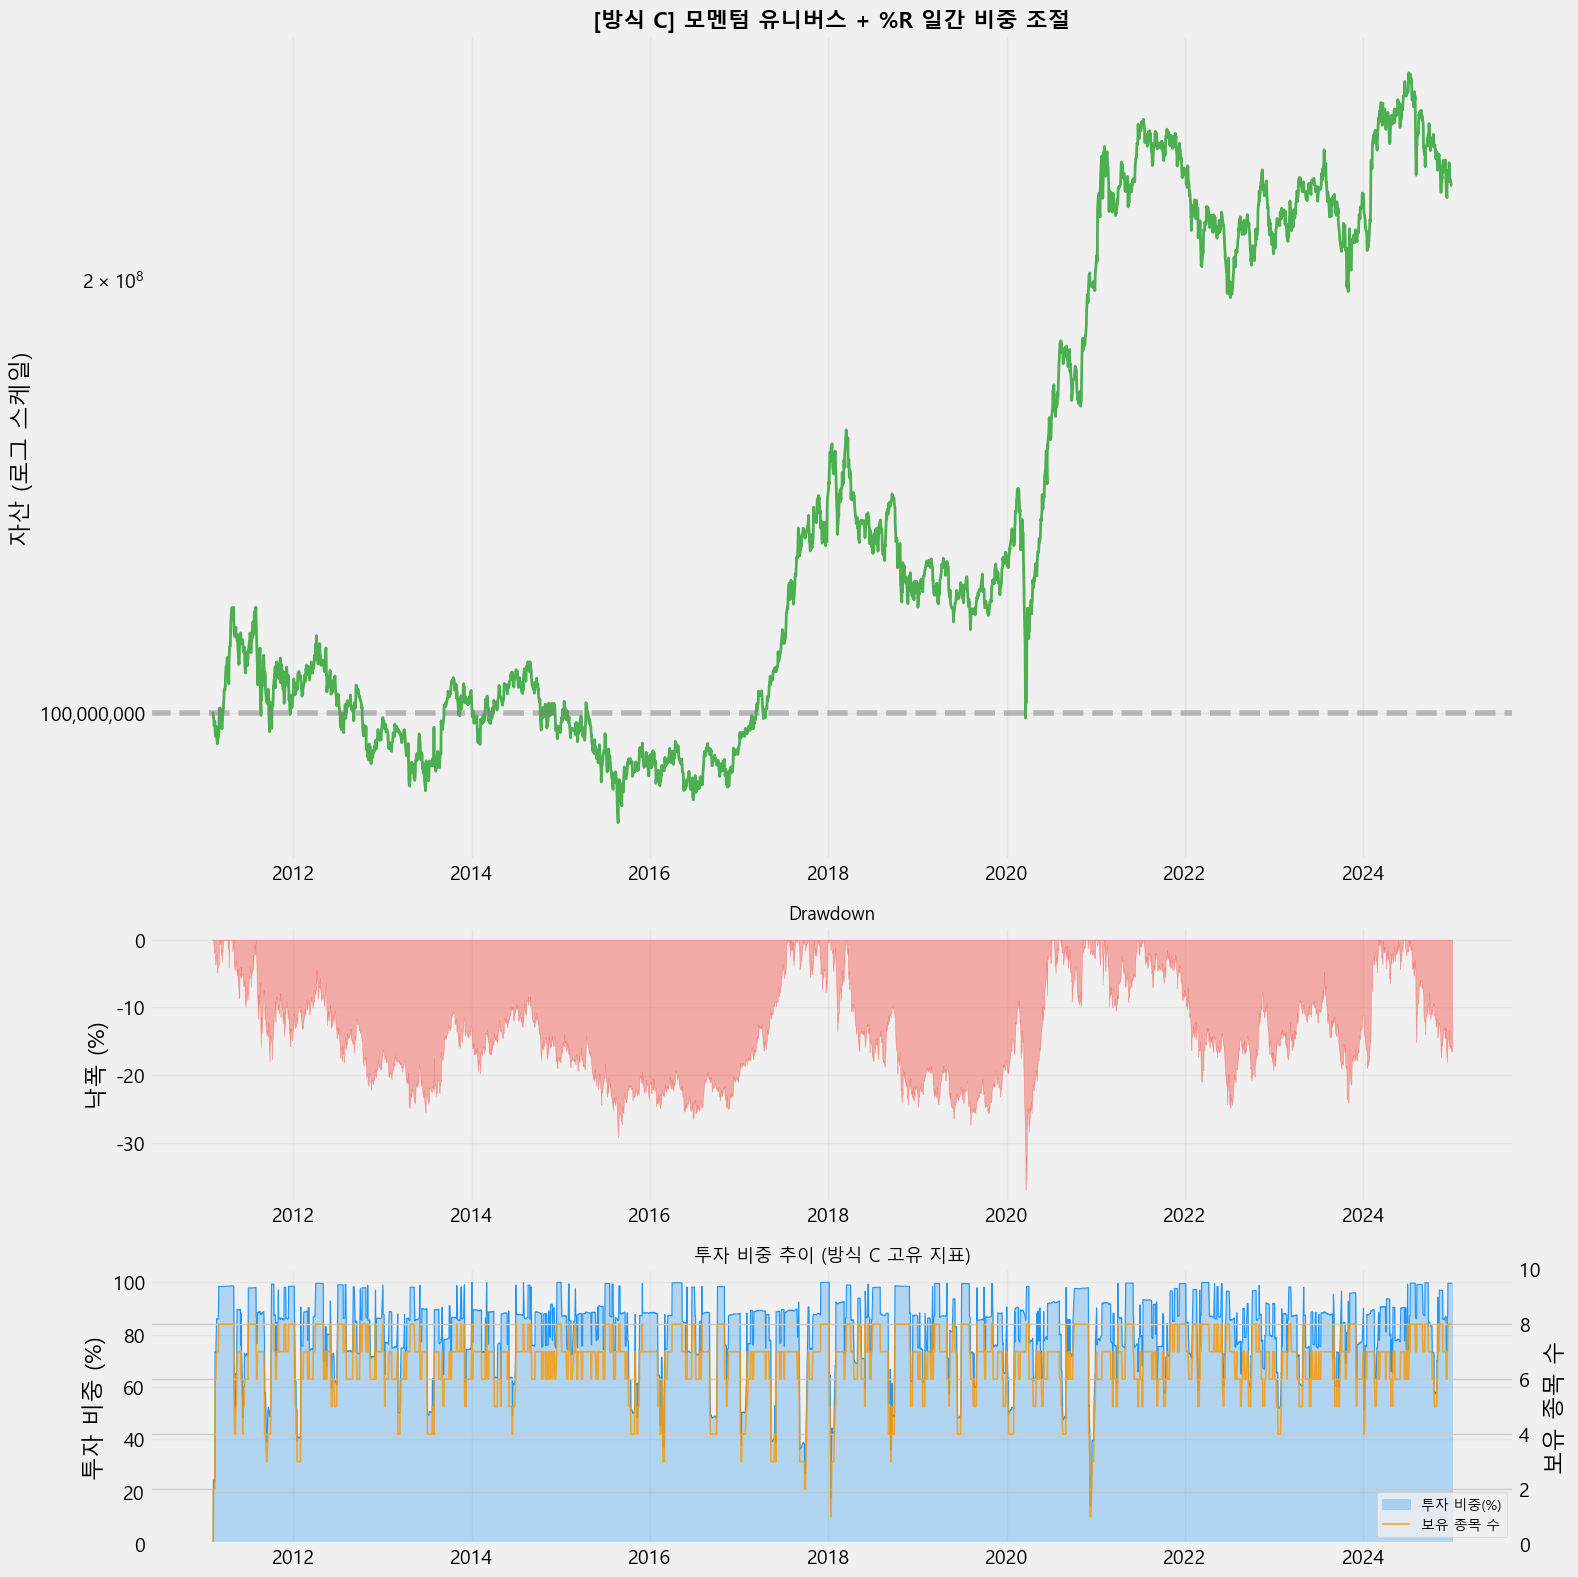

: 

In [ ]:
# ============================================================
# [CELL 11] 시각화 — 자산 곡선 + 낙폭 + 투자 비중 추이
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 16),
                         gridspec_kw={"height_ratios": [3, 1, 1]})

# (1) 자산 곡선
ax1 = axes[0]
ax1.plot(perf_df.index, perf_df["Value"], lw=2, color="#4CAF50")
ax1.axhline(y=CONFIG["INITIAL_CAPITAL"], color="gray", ls="--", alpha=0.5)
ax1.set_yscale("log")
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))
ax1.set_title("[방식 C] 모멘텀 유니버스 + %R 일간 비중 조절", fontsize=16, fontweight="bold")
ax1.set_ylabel("자산 (로그 스케일)")
ax1.grid(True, alpha=0.3)

# (2) 낙폭
ax2 = axes[1]
dd = (perf_df["Value"] / perf_df["Value"].cummax() - 1) * 100
ax2.fill_between(dd.index, dd.values, 0, color="#F44336", alpha=0.4)
ax2.set_ylabel("낙폭 (%)")
ax2.set_title("Drawdown", fontsize=13)
ax2.grid(True, alpha=0.3)

# (3) 투자 비중 & 보유 종목 수 (방식 C 고유)
ax3 = axes[2]
ax3.fill_between(exposure_df.index, exposure_df["Exposure%"], 0,
                 color="#2196F3", alpha=0.3, label="투자 비중(%)")
ax3.plot(exposure_df.index, exposure_df["Exposure%"],
         color="#2196F3", lw=0.8)
ax3.set_ylabel("투자 비중 (%)")
ax3.set_ylim(0, 105)
ax3.set_title("투자 비중 추이 (방식 C 고유 지표)", fontsize=13)
ax3.grid(True, alpha=0.3)

# 보유 종목 수를 보조 축으로
ax3b = ax3.twinx()
ax3b.plot(exposure_df.index, exposure_df["N_Held"],
          color="#FF9800", lw=1.2, alpha=0.8, label="보유 종목 수")
ax3b.set_ylabel("보유 종목 수")
ax3b.set_ylim(0, CONFIG["N_MOM"] + 2)

# 범례 합치기
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

---
## 방식 A/B/C 비교 요약

| | A: 타이밍 진입/청산 | B: 사전 필터 | C: 일간 비중 조절 |
|---|---|---|---|
| **루프** | 일간 | 월간 | 일간 |
| **%R 역할** | 진입/청산 전부 | 과매수 제외만 | 비중 on/off |
| **유니버스 내 재진입** | ✕ (탈락=청산) | ✕ | ✔ (재 크로스 시) |
| **투자 비중 변동** | 0% or 100% | 항상 100% | 0~100% 유동적 |
| **고유 장점** | 눌림목 진입 | 단순함 | 능동적 현금 관리 |
| **주의점** | 미진입 리스크 | %R 효과 제한적 | 거래비용 증가 |

---
## 룩어헤드 방지 체크리스트

| # | 항목 | 처리 |
|---|------|------|
| 1 | 모멘텀 신호 | 월말 리샘플링 + shift(1) → 전월 말 확정 종가만 사용 |
| 2 | %R 계산 | 당일까지의 확정 H/L/C |
| 3 | %R 크로스 판정 | 전일 %R vs 당일 %R (둘 다 확정) |
| 4 | 매수/매도 체결 | 신호 발생 **다음날 시가(Open)** |
| 5 | 포트폴리오 평가 | 당일 종가 기준 |
| 6 | 유니버스 갱신 | 매월 첫 거래일, 전월 말 모멘텀 기준 |